<a href="https://colab.research.google.com/github/Pedro4Albuquerque/09-DIS-Disney-Dire-o-de-Volume/blob/main/prova2_09_pedro_souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09: DIS (Disney) | Direção de Volume:
**Alvo (Y):** 1 (Crescente) ou 0 (Decrescente) em relação ao dia anterior.

**Desafio:** Prever se o fechamento atual é influenciado pelo volume da véspera.
## Aluno : Pedro Henrique Albuquerque Souza

# Pipeline 1 | Carregamento e Digestão dos Dados via API [DIS - Disney]

In [1]:

from typing import List
import requests
import pandas as pd

API_KEY = "YF91FPXACQJ396DA"
SYMBOL = "DIS"

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

dados = data["Time Series (Daily)"]

base_dis = pd.DataFrame.from_dict(
    dados,
    orient="index"
)

base_dis

,1. open,2. high,3. low,4. close,5. volume
2026-06-17,100.6700,102.3600,100.4400,100.8600,11168735
2026-06-16,101.4300,101.9300,100.0500,101.2800,10694557
2026-06-15,100.8800,102.4000,100.5900,101.6900,10265095
2026-06-12,101.0600,101.7685,99.5350,100.0400,8257240
2026-06-11,98.8300,100.7400,98.1000,100.3400,9264363
...,...,...,...,...,...
2026-01-30,111.3600,112.9450,110.9900,112.8000,17895224
2026-01-29,109.6300,111.6700,108.7600,111.5800,11078959
2026-01-28,110.2800,111.4299,109.0000,109.5600,9016629
2026-01-27,111.5000,111.8000,110.0300,110.6100,8888859


## Blibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Organização e Limpeza

In [4]:
base_dis.index = pd.to_datetime(base_dis.index)

base_dis = base_dis.rename(columns={
    "1. open": "Open",
    "2. high": "High",
    "3. low": "Low",
    "4. close": "Close",
    "5. volume": "Volume"
})

base_dis = base_dis.astype(float)

base_dis = base_dis.sort_index()

base_dis

,Open,High,Low,Close,Volume
2026-01-26,111.68,112.4100,111.130,111.31,8859849.0
2026-01-27,111.50,111.8000,110.030,110.61,8888859.0
2026-01-28,110.28,111.4299,109.000,109.56,9016629.0
2026-01-29,109.63,111.6700,108.760,111.58,11078959.0
2026-01-30,111.36,112.9450,110.990,112.80,17895224.0
...,...,...,...,...,...
2026-06-11,98.83,100.7400,98.100,100.34,9264363.0
2026-06-12,101.06,101.7685,99.535,100.04,8257240.0
2026-06-15,100.88,102.4000,100.590,101.69,10265095.0
2026-06-16,101.43,101.9300,100.050,101.28,10694557.0


## Análise Exploratória

 Mostra informações gerais da tabela.

In [5]:
base_dis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2026-01-26 to 2026-06-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    100 non-null    float64
 1   High    100 non-null    float64
 2   Low     100 non-null    float64
 3   Close   100 non-null    float64
 4   Volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


 Gera estatísticas automáticas das colunas numéricas.

In [6]:
base_dis.describe()

,Open,High,Low,Close,Volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,102.779500,103.893026,101.638898,102.700000,1.041068e+07
std,3.932976,4.043076,3.810008,3.983176,4.879322e+06
min,92.890000,94.190000,92.185000,92.420000,5.533717e+06
25%,100.035000,100.983750,99.017500,99.770000,7.820982e+06
50%,102.872500,103.882500,101.810000,102.785000,9.179610e+06
75%,105.110000,106.434975,104.038750,105.142500,1.122837e+07
max,111.680000,112.945000,111.130000,112.800000,3.777850e+07


### Verifica valores vazios (NaN) na tabela.

In [7]:
base_dis.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


### Visualização de Dados

Nesta etapa serão apresentados gráficos relacionados ao fechamento e volume da ação, permitindo observar padrões e oscilações do mercado.

Fechamento das ações

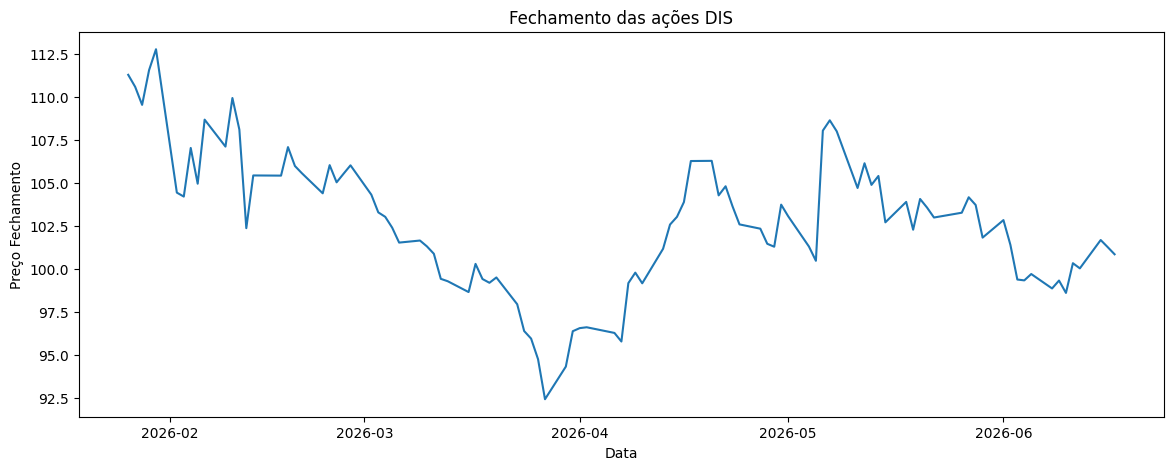

In [8]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Close"])

plt.title("Fechamento das ações DIS")
plt.xlabel("Data")
plt.ylabel("Preço Fechamento")

plt.show()

 Volume negociado

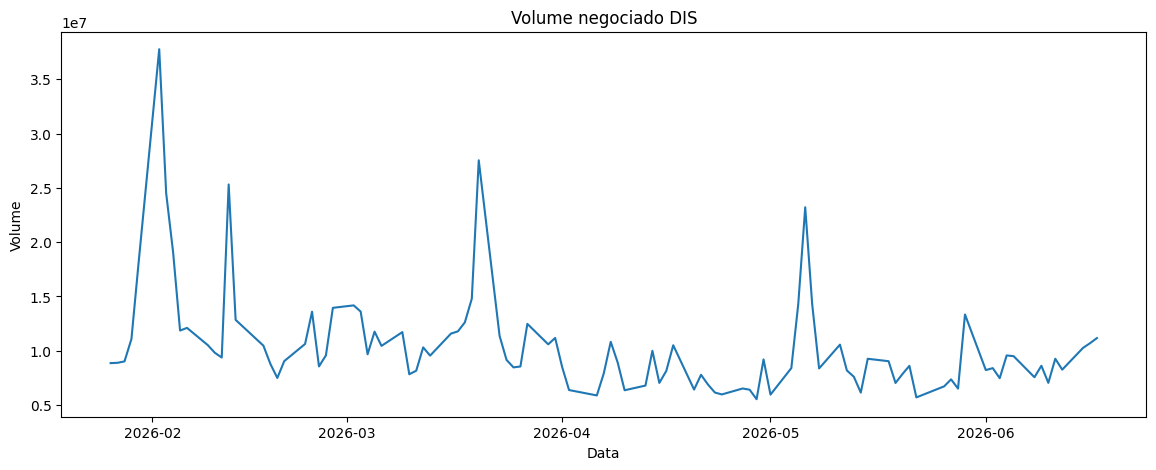

In [9]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Volume"])

plt.title("Volume negociado DIS")
plt.xlabel("Data")
plt.ylabel("Volume")

plt.show()

Correlação

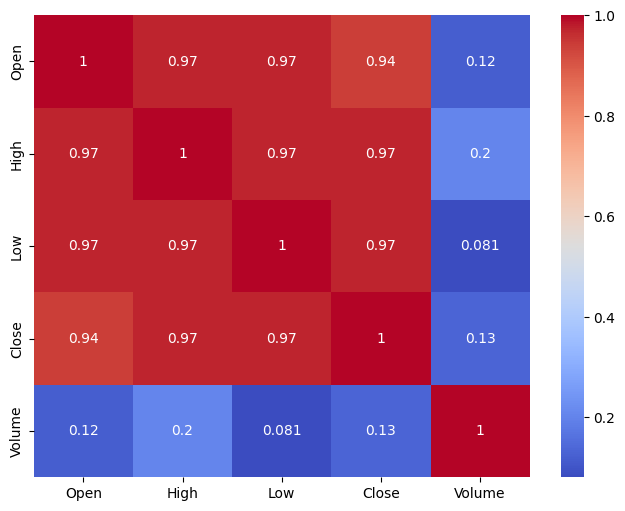

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    base_dis.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

##Engenharia de Features

 Criação do alvo Y

In [11]:
base_dis["fechamento_anterior"] = base_dis["Close"].shift(1)

base_dis["direcao"] = np.where(
    base_dis["Close"] > base_dis["fechamento_anterior"],
    1,
    0
)

Volume da véspera

In [12]:
base_dis["volume_anterior"] = base_dis["Volume"].shift(1)

Removendo valores nulos

In [13]:
base_dis.dropna(inplace=True)

### Separação X e Y

In [14]:
X_dis = base_dis[
    [
      "volume_anterior"
    ]
].values

Y_dis = base_dis["direcao"].values

## Normalização

In [15]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_dis,
    Y_dis,
    test_size=0.20,
    random_state=0,
    shuffle=False
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treinamento = scaler.fit_transform(X_treinamento)
X_teste = scaler.transform(X_teste)

# Pipeline Tree Map | Arvore de Decisão

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
arvore_dis_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_dis_data.fit(X_treinamento, Y_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [19]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [20]:
previsoes_arvore = arvore_dis_data.predict(X_teste)
previsoes_arvore

array([1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
accuracy_score(Y_teste, previsoes_arvore)

0.7

In [23]:
from yellowbrick.classifier import ConfusionMatrix

0.7

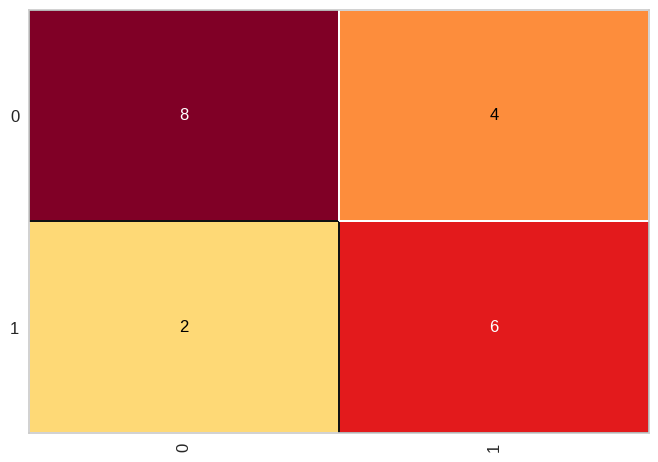

In [24]:
cm_tree = ConfusionMatrix(arvore_dis_data)
cm_tree.fit(X_treinamento, Y_treinamento)
cm_tree.score(X_teste, Y_teste)

In [25]:
print(classification_report(Y_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.60      0.75      0.67         8

    accuracy                           0.70        20
   macro avg       0.70      0.71      0.70        20
weighted avg       0.72      0.70      0.70        20



# Pipeline Random Florest

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [110]:
random_dis = RandomForestClassifier(n_estimators=10, criterion='entropy', max_features='sqrt', random_state=0)

In [111]:
random_dis.fit(X_treinamento, Y_treinamento)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [112]:
previsores_random = random_dis.predict(X_teste)
previsores_random

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [113]:
print("Acurácia do Random Forest:", accuracy_score(Y_teste, previsores_random))

Acurácia do Random Forest: 0.65


In [114]:
print("\nRelatório de Classificação:")
print(classification_report(Y_teste, previsores_random))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.56      0.62      0.59         8

    accuracy                           0.65        20
   macro avg       0.64      0.65      0.64        20
weighted avg       0.66      0.65      0.65        20



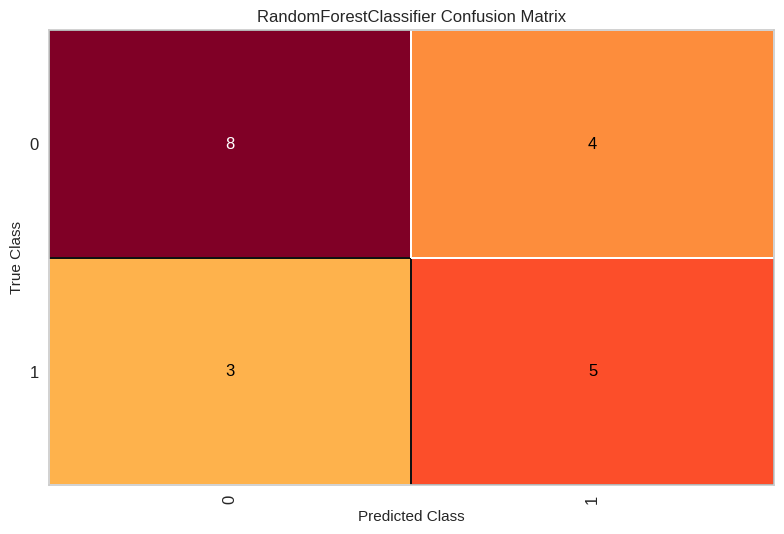

<Axes: title={'center': 'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [115]:
cm_dis_rf = ConfusionMatrix(random_dis)
cm_dis_rf.fit(X_treinamento, Y_treinamento)
cm_dis_rf.score(X_teste, Y_teste)
cm_dis_rf.show()

# Pipeline SVM

In [35]:
from sklearn.svm import SVC

In [36]:
svm_dis = SVC(kernel='rbf', random_state=1, C=2.0)
svm_dis.fit(X_treinamento, Y_treinamento)

SVC(C=2.0, random_state=1)

In [37]:
SVC(C=2.0,break_ties=False,cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=0, shrinking=True, tol=0.001,
    verbose = False)

SVC(C=2.0, random_state=0)

In [38]:
svm_previsoes = svm_dis.predict(X_teste)
svm_previsoes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
accuracy_score(Y_teste, svm_previsoes)

0.6

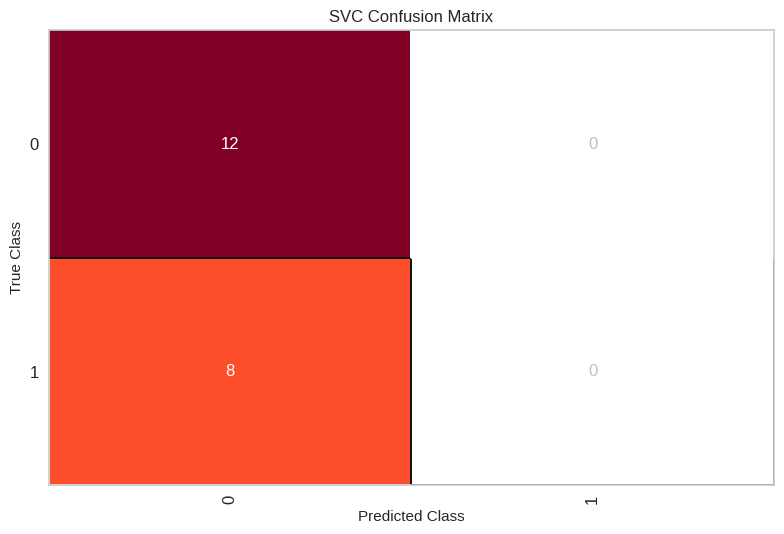

<Axes: title={'center': 'SVC Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [116]:
svm_dis_cm = ConfusionMatrix(svm_dis)
svm_dis_cm.fit(X_treinamento, Y_treinamento)
svm_dis_cm.score(X_teste, Y_teste)
svm_dis_cm.show()

In [41]:
print(classification_report(Y_teste, svm_previsoes))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75        12
           1       0.00      0.00      0.00         8

    accuracy                           0.60        20
   macro avg       0.30      0.50      0.38        20
weighted avg       0.36      0.60      0.45        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Redes Neurais Artificiais

In [81]:
from sklearn.neural_network import MLPClassifier

In [82]:
redeneural_dis = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_dis.fit(X_treinamento, Y_treinamento)

Iteration 1, loss = 0.76062742
Iteration 2, loss = 0.75734004
Iteration 3, loss = 0.75413316
Iteration 4, loss = 0.75100868
Iteration 5, loss = 0.74797486
Iteration 6, loss = 0.74502787
Iteration 7, loss = 0.74216853
Iteration 8, loss = 0.73940472
Iteration 9, loss = 0.73673622
Iteration 10, loss = 0.73415757
Iteration 11, loss = 0.73166505
Iteration 12, loss = 0.72925422
Iteration 13, loss = 0.72692883
Iteration 14, loss = 0.72468574
Iteration 15, loss = 0.72252080
Iteration 16, loss = 0.72044569
Iteration 17, loss = 0.71844969
Iteration 18, loss = 0.71651753
Iteration 19, loss = 0.71465238
Iteration 20, loss = 0.71285229
Iteration 21, loss = 0.71112073
Iteration 22, loss = 0.70945404
Iteration 23, loss = 0.70784153
Iteration 24, loss = 0.70628407
Iteration 25, loss = 0.70477545
Iteration 26, loss = 0.70331719
Iteration 27, loss = 0.70190214
Iteration 28, loss = 0.70053835
Iteration 29, loss = 0.69922372
Iteration 30, loss = 0.69795346
Iteration 31, loss = 0.69672502
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [83]:
redeneural_dis.out_activation_

'logistic'

In [84]:
previsores_randeural = redeneural_dis.predict(X_teste)
previsores_randeural

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [85]:
accuracy_score(Y_teste, redeneural_dis.predict(X_teste))

0.5

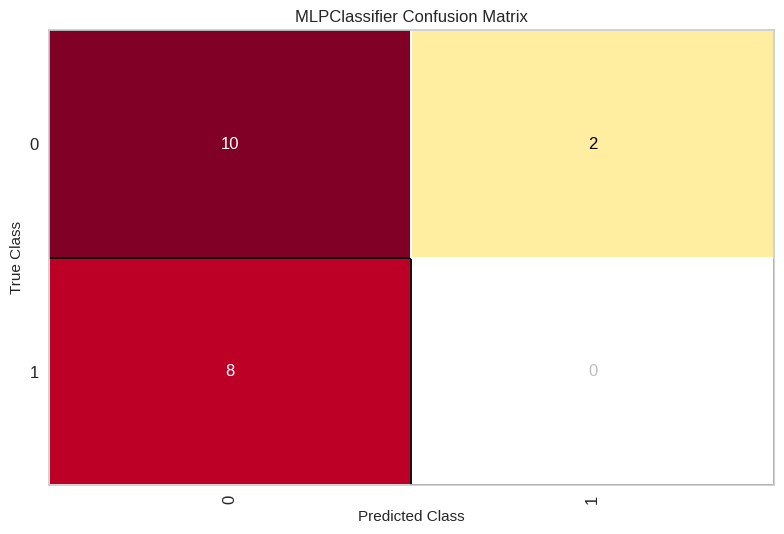

In [118]:
rn_cm= ConfusionMatrix(redeneural_dis)
rn_cm.fit(X_treinamento, Y_treinamento)
rn_cm.score(X_teste, Y_teste)
rn_cm.show();

In [87]:
print(classification_report(Y_teste, previsores_randeural))

              precision    recall  f1-score   support

           0       0.56      0.83      0.67        12
           1       0.00      0.00      0.00         8

    accuracy                           0.50        20
   macro avg       0.28      0.42      0.33        20
weighted avg       0.33      0.50      0.40        20



# Pipeline K-Nearest Neighbors (KNN)

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [89]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=2)

In [90]:
parametros = {'n_neighbors': [3, 5, 10],
              'p': [1, 2]}

In [91]:
grid_dis = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=parametros,
    cv=tscv
)

In [92]:
grid_dis.fit(X_treinamento, Y_treinamento)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=2, test_size=None),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 10], 'p': [1, 2]})

In [93]:
melhor_paremetro_dis = grid_dis.best_params_
melhor_resultado_dis = grid_dis.best_score_

print("Melhor parâmetro:", melhor_paremetro_dis)
print("Melhor resultado:", melhor_resultado_dis)

Melhor parâmetro: {'n_neighbors': 10, 'p': 1}
Melhor resultado: 0.6730769230769231
